### Step 1: Import Required Libraries
We first import Python libraries for data handling, machine learning,
and visualization.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


### Step 2: Load NASA CMAPSS Dataset
We load the training, testing, and RUL (Remaining Useful Life) files.  
Each row represents an engine cycle with 21 sensor readings and 3 operating settings.


In [ ]:
# Define column names: ID, cycle, 3 operating settings, 21 sensors
COLS = ['id', 'cycle', 'op_setting1', 'op_setting2', 'op_setting3'] + [f'sensor{i}' for i in range(1,22)]

# Load data
train_raw = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None, names=COLS)
test_raw  = pd.read_csv("test_FD001.txt",  sep=r"\s+", header=None, names=COLS)
rul_last  = pd.read_csv("RUL_FD001.txt",   sep=r"\s+", header=None, names=['RUL_last_cycle'])

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print("RUL file shape:", rul_last.shape)
train_raw.head()


Train shape: (20631, 26)
Test shape: (13096, 26)
RUL file shape: (100, 1)


,id,cycle,op_setting1,op_setting2,op_setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### Step 3: Add RUL (Remaining Useful Life) to Training Data
For each engine, the last cycle is considered failure.  
RUL = (max cycle for engine) – (current cycle).


In [ ]:
def add_rul_column(df):
    max_cycle = df.groupby('id')['cycle'].max().rename('max_cycle')
    df = df.merge(max_cycle, on='id', how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']
    return df

train = add_rul_column(train_raw.copy())
train[['id','cycle','RUL']].head()


,id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


### Step 4: Explore the Dataset
We check number of engines, cycle range, and visualize a few sensor trends.


Engines in train: 100
Cycle range: 1 - 362


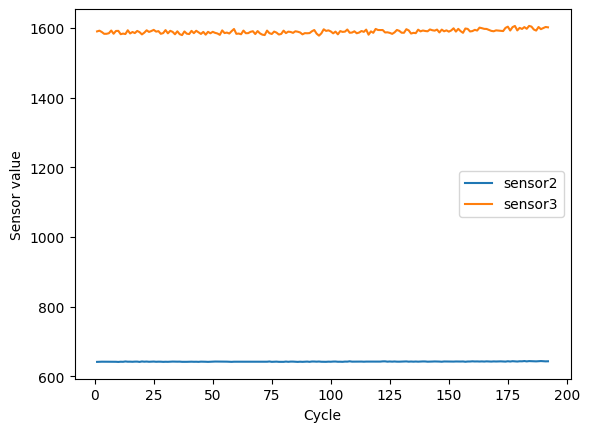

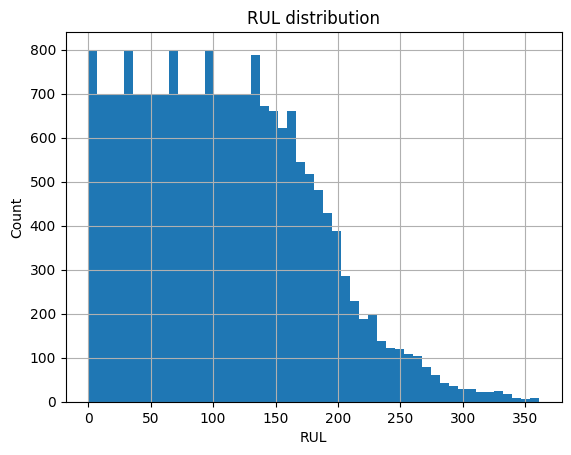

In [ ]:
print("Engines in train:", train['id'].nunique())
print("Cycle range:", train['cycle'].min(), "-", train['cycle'].max())

# Plot sensors for one engine
engine1 = train[train['id'] == 1]
plt.plot(engine1['cycle'], engine1['sensor2'], label='sensor2')
plt.plot(engine1['cycle'], engine1['sensor3'], label='sensor3')
plt.xlabel("Cycle"); plt.ylabel("Sensor value"); plt.legend(); plt.show()

# RUL distribution
train['RUL'].hist(bins=50)
plt.xlabel("RUL"); plt.ylabel("Count"); plt.title("RUL distribution"); plt.show()


### Step 5: Prepare Features for Modeling
We remove ID, cycle counters, and RUL (target).  
We also drop low-variance features (no information).


In [ ]:
# Define features
FEATURE_COLS = [c for c in train.columns if c not in ['id','cycle','max_cycle','RUL']]
X_all = train[FEATURE_COLS]
y_all = train['RUL']

# Variance filter
vt = VarianceThreshold(threshold=1e-5)
X_all_vf = vt.fit_transform(X_all)

print("Original feature count:", len(FEATURE_COLS))
print("Kept after variance filter:", X_all_vf.shape[1])


Original feature count: 24
Kept after variance filter: 14


### Step 6: Train-Test Split and Scaling
We split into training and validation sets (80/20).  
Scaling is applied for Linear Regression (not required for Random Forest).


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_all_vf, y_all, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)


### Step 7: Train Baseline Models
We train two baseline models:  
- Linear Regression (simple baseline)  
- Random Forest (handles nonlinear sensor patterns)


In [ ]:
def eval_regression(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label:18s} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")
    return mae, rmse

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_val_s)
mae_lr, rmse_lr = eval_regression(y_val, pred_lr, "Linear Regression")

# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
mae_rf, rmse_rf = eval_regression(y_val, pred_rf, "Random Forest")


Linear Regression  | MAE: 34.05 | RMSE: 44.33
Random Forest      | MAE: 29.48 | RMSE: 41.26


### Step 8: Feature Engineering
To make our research unique, we add health indicators:  
- Rolling average of sensor values (smooth trends)  
- Rate of change (difference from previous cycle)

We apply this to 3 key sensors (2, 3, 7).


In [ ]:
for sensor in ['sensor2', 'sensor3', 'sensor7']:
    train[f'{sensor}_ma5'] = train.groupby('id')[sensor].transform(lambda x: x.rolling(5, 1).mean())
    test_raw[f'{sensor}_ma5'] = test_raw.groupby('id')[sensor].transform(lambda x: x.rolling(5, 1).mean())

    train[f'{sensor}_diff'] = train.groupby('id')[sensor].diff().fillna(0)
    test_raw[f'{sensor}_diff'] = test_raw.groupby('id')[sensor].diff().fillna(0)

print("New features added:", [c for c in train.columns if 'ma5' in c or 'diff' in c])


New features added: ['sensor2_ma5', 'sensor2_diff', 'sensor3_ma5', 'sensor3_diff', 'sensor7_ma5', 'sensor7_diff']


### Step 9: Re-Train Models with Engineered Features
We now include the engineered features in training and re-train the models.


In [ ]:
# Extended features
FEATURE_COLS_EXT = [c for c in train.columns if c not in ['id','cycle','max_cycle','RUL']]
X_all_ext = train[FEATURE_COLS_EXT]
y_all = train['RUL']

# Variance filter again
vt = VarianceThreshold(threshold=1e-5)
X_all_vf_ext = vt.fit_transform(X_all_ext)

# Train/test split
X_train_ext, X_val_ext, y_train_ext, y_val_ext = train_test_split(X_all_vf_ext, y_all, test_size=0.2, random_state=42)

# Scaling for LR
scaler_ext = StandardScaler()
X_train_s_ext = scaler_ext.fit_transform(X_train_ext)
X_val_s_ext   = scaler_ext.transform(X_val_ext)

# Linear Regression (extended)
lr_ext = LinearRegression()
lr_ext.fit(X_train_s_ext, y_train_ext)
pred_lr_ext = lr_ext.predict(X_val_s_ext)
mae_lr_ext, rmse_lr_ext = eval_regression(y_val_ext, pred_lr_ext, "LR + features")

# Random Forest (extended)
rf_ext = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_ext.fit(X_train_ext, y_train_ext)
pred_rf_ext = rf_ext.predict(X_val_ext)
mae_rf_ext, rmse_rf_ext = eval_regression(y_val_ext, pred_rf_ext, "RF + features")


LR + features      | MAE: 33.79 | RMSE: 44.06
RF + features      | MAE: 28.59 | RMSE: 40.26


(a) Plot of RUL Degradation over Cycles

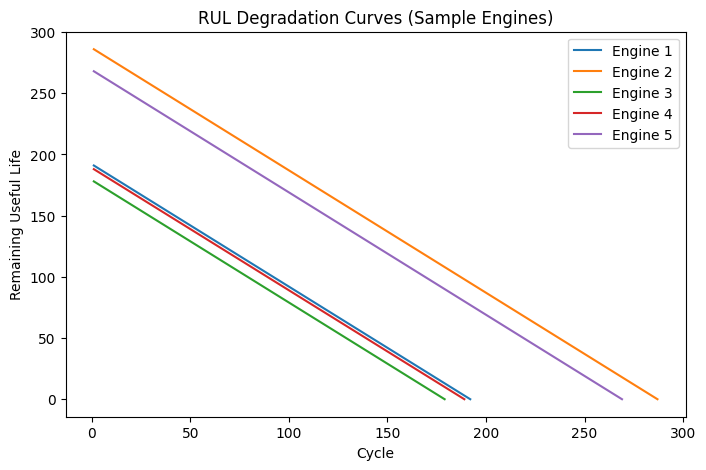

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: FD001 dataset
train_df = pd.read_csv("train_FD001.txt", sep=" ", header=None)
train_df = train_df.dropna(axis=1, how='all')
train_df.columns = ["unit","cycle"] + [f"op_set{i}" for i in range(1,4)] + [f"sensor{i}" for i in range(1,22)]

# Generate RUL values
max_cycle = train_df.groupby("unit")["cycle"].max().reset_index()
train_df = train_df.merge(max_cycle, on="unit", suffixes=("", "_max"))
train_df["RUL"] = train_df["cycle_max"] - train_df["cycle"]

# Plot RUL degradation for first 5 engines
plt.figure(figsize=(8,5))
for i in range(1,6):
    eng = train_df[train_df["unit"]==i]
    plt.plot(eng["cycle"], eng["RUL"], label=f"Engine {i}")
plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life")
plt.title("RUL Degradation Curves (Sample Engines)")
plt.legend()
plt.show()


(b) Feature Trend Example

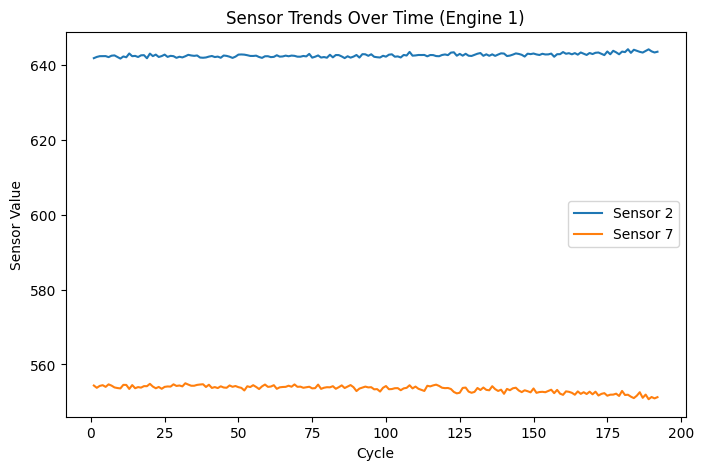

In [ ]:
plt.figure(figsize=(8,5))
eng = train_df[train_df["unit"]==1]
plt.plot(eng["cycle"], eng["sensor2"], label="Sensor 2")
plt.plot(eng["cycle"], eng["sensor7"], label="Sensor 7")
plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor Trends Over Time (Engine 1)")
plt.legend()
plt.show()


(c) Model Comparison Bar Chart

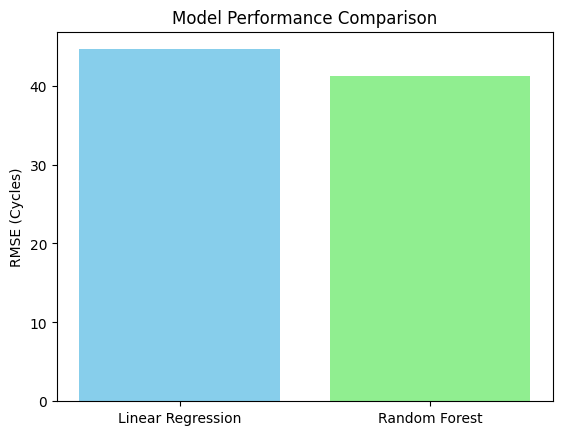

In [ ]:
import numpy as np

models = ["Linear Regression", "Random Forest"]
rmse_scores = [44.6, 41.26]  # replace with your results
plt.bar(models, rmse_scores, color=['skyblue','lightgreen'])
plt.ylabel("RMSE (Cycles)")
plt.title("Model Performance Comparison")
plt.show()


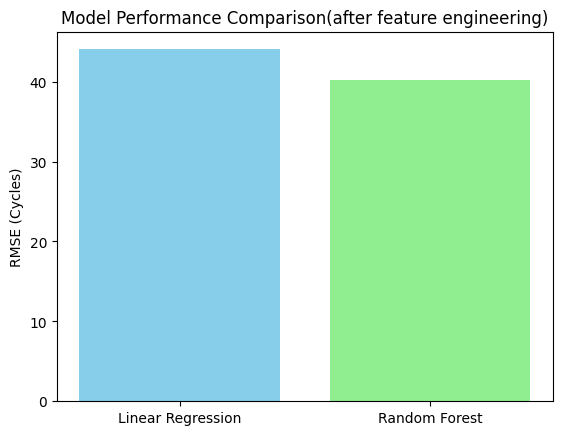

In [ ]:
import numpy as np

models = ["Linear Regression", "Random Forest"]
rmse_scores = [44.06, 40.26]  # replace with your results
plt.bar(models, rmse_scores, color=['skyblue','lightgreen'])
plt.ylabel("RMSE (Cycles)")
plt.title("Model Performance Comparison(after feature engineering)")
plt.show()

Summary of tables


In [ ]:
import pandas as pd

# Define column names for CMAPSS
col_names = ["unit","cycle"] + [f"op_set{i}" for i in range(1,4)] + [f"sensor{i}" for i in range(1,22)]

# Load FD001 training dataset
df = pd.read_csv("train_FD001.txt", sep=" ", header=None)
df = df.dropna(axis=1, how='all')
df.columns = col_names

# Dataset summary
num_units = df["unit"].nunique()
total_cycles = len(df)
avg_cycles_per_unit = df.groupby("unit")["cycle"].max().mean()

summary = pd.DataFrame({
    "Dataset": ["FD001"],
    "Units": [num_units],
    "Total Cycles": [total_cycles],
    "Avg Cycles per Unit": [round(avg_cycles_per_unit, 2)],
    "Operating Conditions": [1],
    "Fault Modes": [1]
})

print(summary)


  Dataset  Units  Total Cycles  Avg Cycles per Unit  Operating Conditions  \
0   FD001    100         20631               206.31                     1   

   Fault Modes  
0            1  


In [ ]:
import pandas as pd

# Define column names as per NASA CMAPSS dataset format
col_names = ["unit","cycle"] + [f"op_set{i}" for i in range(1,4)] + [f"sensor{i}" for i in range(1,22)]

def summarize_dataset(file_path, dataset_name, operating_conditions, fault_modes):
    df = pd.read_csv(file_path, sep=" ", header=None)
    df = df.dropna(axis=1, how='all')  # remove empty columns
    df.columns = col_names

    num_units = df["unit"].nunique()
    total_cycles = len(df)
    avg_cycles_per_unit = df.groupby("unit")["cycle"].max().mean()

    return {
        "Dataset": dataset_name,
        "Units": num_units,
        "Total Cycles": total_cycles,
        "Avg Cycles per Unit": round(avg_cycles_per_unit, 2),
        "Operating Conditions": operating_conditions,
        "Fault Modes": fault_modes
    }

# Example: FD001
fd001_summary = summarize_dataset("train_FD001.txt", "FD001", 1, 1)

# If you also have FD002, FD003, FD004, uncomment these:
# fd002_summary = summarize_dataset("train_FD002.txt", "FD002", 6, 1)
# fd003_summary = summarize_dataset("train_FD003.txt", "FD003", 1, 2)
# fd004_summary = summarize_dataset("train_FD004.txt", "FD004", 6, 2)

# Create a DataFrame for neat table
summary_df = pd.DataFrame([fd001_summary])
# If you added others: pd.DataFrame([fd001_summary, fd002_summary, fd003_summary, fd004_summary])

print(summary_df.to_string(index=False))


Dataset  Units  Total Cycles  Avg Cycles per Unit  Operating Conditions  Fault Modes
  FD001    100         20631               206.31                     1            1


In [ ]:
import pandas as pd

# Define column names as per NASA CMAPSS dataset format
col_names = ["unit","cycle"] + [f"op_set{i}" for i in range(1,4)] + [f"sensor{i}" for i in range(1,22)]

def summarize_dataset(train_file, test_file, dataset_name, operating_conditions, fault_modes):
    # Load training data
    train_df = pd.read_csv(train_file, sep=" ", header=None)
    train_df = train_df.dropna(axis=1, how='all')
    train_df.columns = col_names

    # Load test data
    test_df = pd.read_csv(test_file, sep=" ", header=None)
    test_df = test_df.dropna(axis=1, how='all')
    test_df.columns = col_names

    # Training set summary
    num_units = train_df["unit"].nunique()
    total_train_cycles = len(train_df)
    avg_cycles_per_unit = train_df.groupby("unit")["cycle"].max().mean()

    # Test set summary
    num_test_units = test_df["unit"].nunique()
    total_test_cycles = len(test_df)
    avg_test_cycles_per_unit = test_df.groupby("unit")["cycle"].max().mean()

    return {
        "Dataset": dataset_name,
        "Units (Train)": num_units,
        "Train Cycles": total_train_cycles,
        "Avg Cycles per Train Unit": round(avg_cycles_per_unit, 2),
        "Units (Test)": num_test_units,
        "Test Cycles": total_test_cycles,
        "Avg Cycles per Test Unit": round(avg_test_cycles_per_unit, 2),
        "Operating Conditions": operating_conditions,
        "Fault Modes": fault_modes
    }

# Example for FD001 (adjust file paths as needed)
fd001_summary = summarize_dataset("train_FD001.txt", "test_FD001.txt", "FD001", 1, 1)

# If you have other datasets, uncomment and run:
# fd002_summary = summarize_dataset("train_FD002.txt", "test_FD002.txt", "FD002", 6, 1)
# fd003_summary = summarize_dataset("train_FD003.txt", "test_FD003.txt", "FD003", 1, 2)
# fd004_summary = summarize_dataset("train_FD004.txt", "test_FD004.txt", "FD004", 6, 2)

# Create summary table
summary_df = pd.DataFrame([fd001_summary])
# For multiple: summary_df = pd.DataFrame([fd001_summary, fd002_summary, fd003_summary, fd004_summary])

print(summary_df.to_string(index=False))


Dataset  Units (Train)  Train Cycles  Avg Cycles per Train Unit  Units (Test)  Test Cycles  Avg Cycles per Test Unit  Operating Conditions  Fault Modes
  FD001            100         20631                     206.31           100        13096                    130.96                     1            1
